# 01 - Baseline: pre-genAI Lean Startup (2019)

This notebook reproduces the classical Lean Startup baseline described in the paper. It corresponds to the world before the diffusion of frontier large language models, in which the cost gradient across layers of the entrepreneurial process was relatively flat and the Lean Startup methodology allocated effort roughly evenly.

**What you should observe:**
- Survival rate is low (around 4-5% in Monte Carlo). Building an MVP and reaching product-market fit was harder.
- The Damodaran inverted discount is essentially identical to the classical discount: there is no inversion regime in the pre-genAI baseline.
- ARR ramp is slow because the team must climb the TRL ladder unaided by AI.

All parameters are editable in `config/scenarios/pre_genai_2019.yaml`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.simulation import load_scenario, run_single_simulation, run_monte_carlo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

config = load_scenario('../config/scenarios/pre_genai_2019.yaml',
                       '../config/parameters.yaml')
print('Scenario:', config['scenario_name'])

Scenario: pre_genai_2019_baseline


## Deterministic single trajectory

In [2]:
result = run_single_simulation(config)
print(f'Survived: {result.survived}')
print(f'Months run: {result.months_run}')
print(f'Final ARR: ${result.final_arr_usd:,.0f}')
print(f'Final team size: {result.final_team_size:.1f}')
print()
print('Valuations at exit:')
for k, v in result.valuations_at_exit.items():
    print(f'  {k:30s}: ${v:>15,.0f}')

Survived: False
Months run: 67
Final ARR: $1,029,468
Final team size: 108.0

Valuations at exit:
  vc_method                     : $      3,500,133
  comparable_multiples          : $      8,235,744
  damodaran_classical           : $     20,096,859
  damodaran_inverted            : $     20,228,808


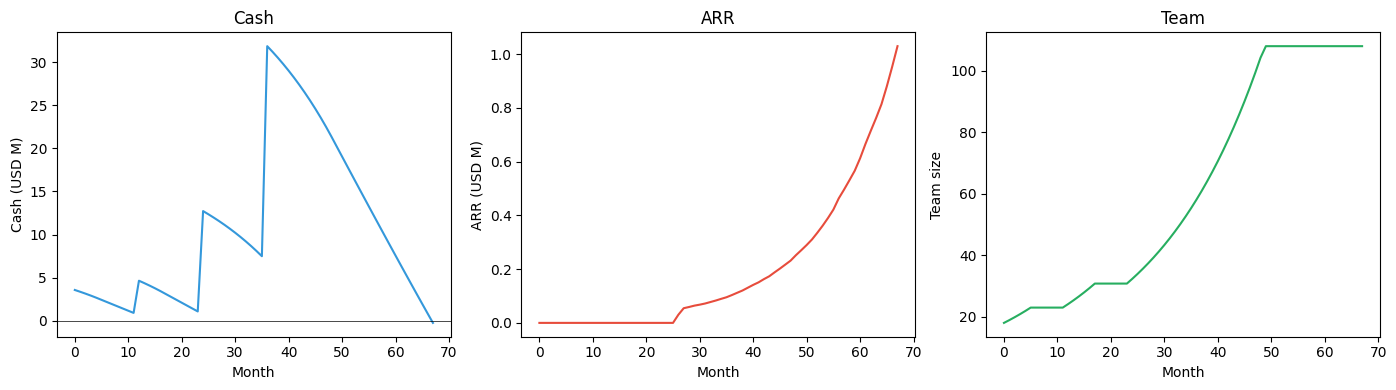

In [3]:
df = pd.DataFrame(result.history)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(df['month'], df['cash_usd'] / 1e6, color='#3498db')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Cash (USD M)'); axes[0].set_title('Cash')
axes[1].plot(df['month'], df['arr_usd'] / 1e6, color='#e74c3c')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('ARR (USD M)'); axes[1].set_title('ARR')
axes[2].plot(df['month'], df['team_size'], color='#27ae60')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('Team size'); axes[2].set_title('Team')
plt.tight_layout()
plt.show()

## Monte Carlo (1000 runs)

In [4]:
df_mc = run_monte_carlo(config, n_runs=1000, show_progress=False)
print(f'Survival rate: {100 * df_mc["survived"].mean():.1f}%')
print(f'Median final ARR (survivors): ${df_mc[df_mc["survived"]]["final_arr_usd"].median():,.0f}')

Survival rate: 4.3%
Median final ARR (survivors): $9,327,768


**Observation.** In the pre-genAI 2019 baseline, the inversion regime almost never activates: layer-4 substitutability is set to 0.05 in the YAML, so even when a Monte Carlo perturbation pushes the team layer-4 share above the threshold, the inversion strength term (which multiplies by ai_substitution_potential) remains very small. This is exactly what the framework predicts.